In [1]:
import torch
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import load_model_and_tokenizer

device = get_device()
# device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [2]:
from reasoning_from_scratch.ch03 import render_prompt

# Answer: 83
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
print(prompt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


In [7]:
from reasoning_from_scratch.ch02 import generate_text_basic_stream_cache

def generate_text_stream_concat_flex(
    model, tokenizer, prompt, device, max_new_tokens,
    verbose=False,
    generate_func=None,
    **generate_kwargs
):
    if generate_func is None:
        generate_func = generate_text_basic_stream_cache

    input_ids = torch.tensor(
        tokenizer.encode(prompt), device=device
    ).unsqueeze(0)

    generated_ids = []
    for token in generate_func(
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs,
    ):
        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id.item())

        if verbose:
            print(tokenizer.decode(next_token_id.tolist()), end="", flush=True)

    return tokenizer.decode(generated_ids)

In [8]:
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_basic_stream_cache
)

 \boxed{20}

In [9]:
prompt_cot = prompt + " \n\nExplain step by step."

response_cot = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
)

 To solve the problem, we need to find the value of \( x \) such that half the value of \( 3x - 9 \) is equal to \( x + 37 \).

### Step 1: Set up the equation
We are given that half the value of \( 3x - 9 \) is equal to \( x + 37 \). This can be written as:
\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 2: Eliminate the fraction
To eliminate the fraction, multiply both sides of the equation by 2:
\[
2 \cdot \frac{1}{2}(3x - 9) = 2(x + 37)
\]
Simplifying both sides:
\[
3x - 9 = 2x + 74
\]

### Step 3: Solve for \( x \)
Subtract \( 2x \) from both sides to isolate \( x \):
\[
3x - 2x - 9 = 74
\]
Simplify:
\[
x - 9 = 74
\]
Add 9 to both sides to solve for \( x \):
\[
x = 74 + 9
\]
\[
x = 83
\]

### Final Answer:
\[
\boxed{83}
\]

In [10]:
ex_prompt = "The capital of Japan is"
response = generate_text_stream_concat_flex(
    model, tokenizer, ex_prompt, device,
    max_new_tokens=1, verbose=True
)

 Tokyo

In [11]:
input_token_ids = torch.tensor(
    tokenizer.encode(ex_prompt), device=device
).unsqueeze(0)
print(input_token_ids)

tensor([[ 785, 6722,  315, 6323,  374]], device='mps:0')


In [12]:
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape) # 151936 is the vocab size

torch.Size([1, 151936])


In [13]:
max_token_id = torch.argmax(next_token_logits)
print(f"Token ID: {max_token_id}")
print(f"Decoded token: '{tokenizer.decode([max_token_id])}'")

Token ID: 26194
Decoded token: ' Tokyo'


In [16]:
import matplotlib.pyplot as plt

def plot_scores_bar(
    next_token_logits, start=26_100, end=26_200,
    arrow=True, ylabel="Logit value"
):
    x = torch.arange(start, end)
    logits_section = next_token_logits[0, start:end].float().cpu()

    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)

    if arrow:
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "Tokyo",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={
                "facecolor": "black", "arrowstyle": "->", "lw": 1.5
            },
            fontsize=10,
        )
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

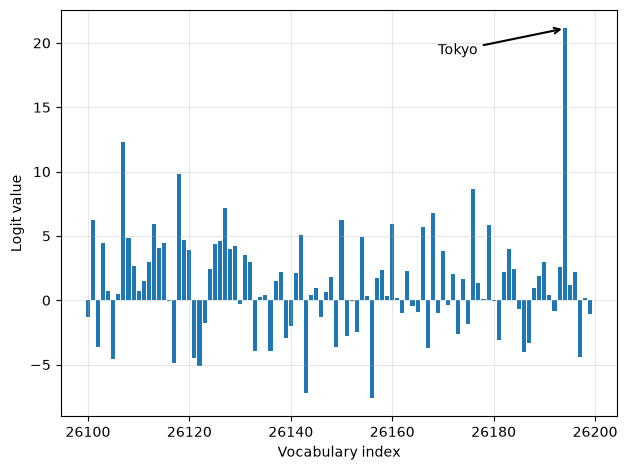

In [17]:
plot_scores_bar(next_token_logits)

In [18]:
def scale_logits_by_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature

In [23]:
def plot_logits_with_temperature(next_token_logits, start=26_100, end=26_200, temps=(0.5, 5.0)):
    x = torch.arange(start, end)
    logits_orig = next_token_logits[0, start:end].float().cpu()

    logits_scaled = [
        scale_logits_by_temperature(logits_orig, T) for T in temps
    ]

    plt.plot(x, logits_orig, label="Original logits", lw=2)
    plt.plot(x, logits_scaled[0], label=f"T={temps[0]} (sharper)", ls="--", lw=1)
    plt.plot(x, logits_scaled[1], label=f"T={temps[1]} (flatter)", ls=":", lw=3)

    max_idx = torch.argmax(logits_orig)
    plt.annotate(
        "Tokyo",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )

    plt.xlabel("Vocabulary index")
    plt.ylabel("Logit value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

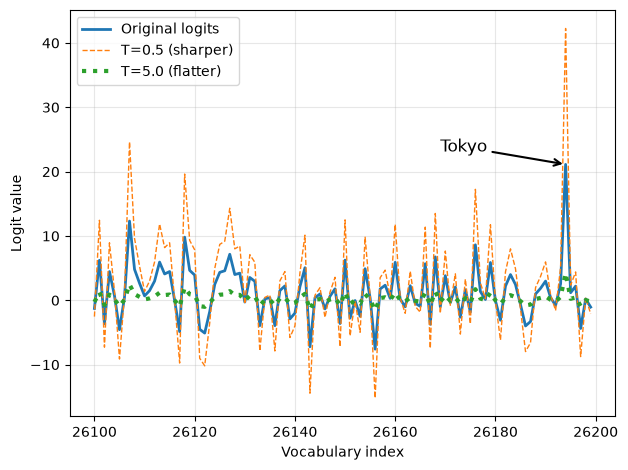

In [24]:
plot_logits_with_temperature(
    next_token_logits,
    temps=(0.5, 5.0)
)

In [25]:
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)
next_token_probas = torch.softmax(rescaled_logits, dim=-1)

In [26]:
print("Probability sum:", torch.sum(next_token_probas))

Probability sum: tensor(1., device='mps:0', dtype=torch.bfloat16)


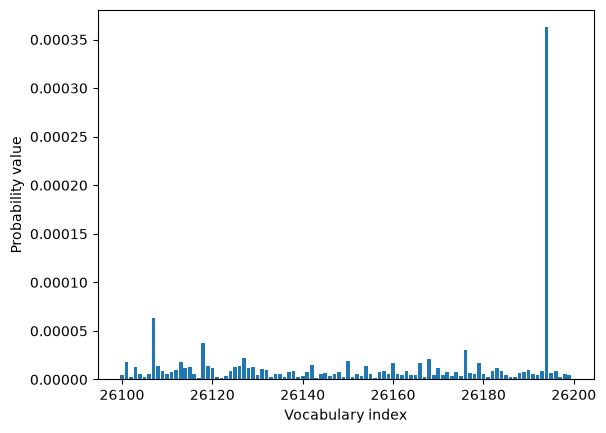

In [27]:
plot_scores_bar(next_token_probas, arrow=False, ylabel="Probability value")

In [33]:
print("Token ID 26,194 probability:", next_token_probas[:, 26194])

Token ID 26,194 probability: tensor([0.0004], device='mps:0', dtype=torch.bfloat16)


In [32]:
print("Highest probability:", max(next_token_probas.squeeze(0)))

Highest probability: tensor(0.0004, device='mps:0', dtype=torch.bfloat16)


In [35]:
torch.manual_seed(123)
print("Sample token:", torch.multinomial(next_token_probas.cpu(), num_samples=1))

Sample token: tensor([[65094]])


In [36]:
def count_samples(probas, num_samples=1000, threshold=1, tokenizer=None):
    samples = torch.multinomial(probas.cpu(), num_samples=num_samples, replacement=True)
    counts = torch.bincount(samples.squeeze(0), minlength=1) # count how often each index was selected

    for i, c in enumerate(counts):
        if c > threshold:
            if tokenizer is None:
                print(f"Vocab index {i}: {c.item()}x")
            else:
                print(f"'{tokenizer.decode([i])}': {c.item()}x")

In [37]:
count_samples(next_token_probas, tokenizer=tokenizer)

' __': 2x
' nil': 2x
'.Is': 2x
' CONNECTION': 2x
'...,': 2x
'rounded': 2x
'.translatesAutoresizingMaskIntoConstraints': 2x
' Miy': 2x
' harmed': 2x
'쵸': 2x


In [47]:
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.45), dim=-1
)
count_samples(probas_lowT, tokenizer=tokenizer)

'
': 2x
' __': 38x
' called': 4x
' Tokyo': 929x
' ____': 17x
' Kyoto': 6x


In [48]:
from reasoning_from_scratch.qwen3 import KVCache

@torch.inference_mode()
def generate_text_temp_stream_cache(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    out = model(token_ids, cache=cache)[:, -1] # get logits
    for _ in range(max_new_tokens):
        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)
        else:
            logits = scale_logits_by_temperature(out, temperature)
            probas = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)

        if (eos_token_id is not None and torch.all(next_token == eos_token_id)):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [51]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1 # A temperature of 0 always chooses a greedy decoding, always picks highest probability
)

 We begin with the equation \(\frac{1}{2}(3x - 9) = x + 37\).
First, distribute the \(\frac{1}{2}\) on the left-side of the equation to get \(3x - 9 = 2(x + 37)\).
Then simplify the right side of the equation by using the distributive property and combining like terms: \(3x - 9 = 2x + 74\).
Next, subtract \(2x\) from both sides of the equation to get \(x - 9 = 2x + 74\).
Next, subtract \(x\) from both sides of the equation to reduce the number of \(x\) terms on the right side to exactly 1: \(-9 = x + 74\).
Finally, subtract 74 from both sides of the equation to get \(x = -83\).
The value of \(x\) is \(\boxed{-83}\).

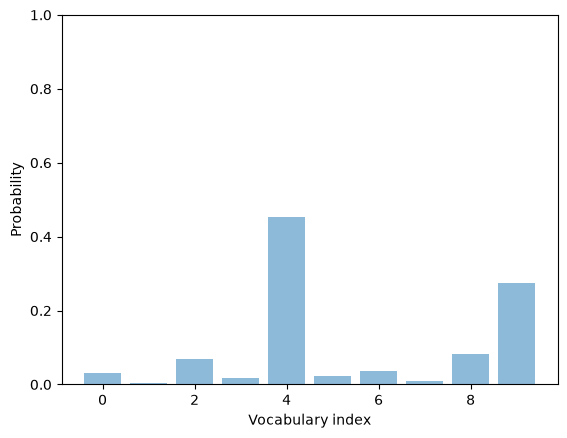

In [52]:
"""
Selecting subset of top-p (4 step process):

1) sorting the token probabilities
2) computing their cumulative sum
3) selecting the subset that satisfies the top-p cutoff
4) and renormalizing the remaining probabilities so that they again form a valid distribution.

toy-example with fake data
"""

toy_logits = torch.tensor(
    [-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)

toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)
toy_probas = torch.softmax(toy_logits_scaled, dim=-1) # convert to probabilities

plt.bar(
    torch.arange(len(toy_probas)), toy_probas,
    alpha=0.5
)

plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
plt.show()

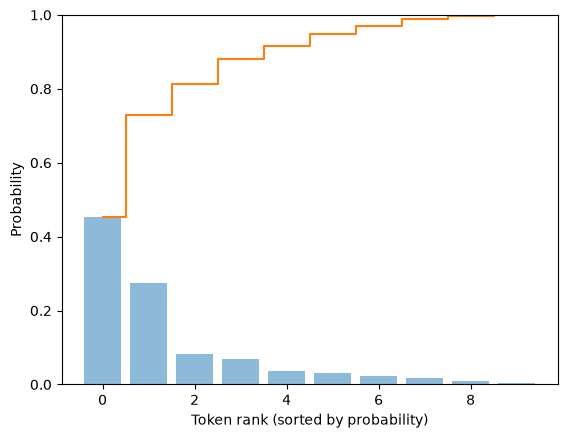

In [53]:
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True) # descending order
cumsum = torch.cumsum(sorted_probas, dim=-1) # cumulative sum

plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas,
    alpha=0.5
)
plt.step(
    torch.arange(len(cumsum)), cumsum,
    where="mid", color="C1", label="Cumulative sum"
)

plt.ylim([0, 1])
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.show()

In [54]:
# top-p filering
top_p = 0.8
keep_mask = cumsum <= top_p
n_kept = torch.sum(keep_mask).item()
print("Cumulative sum:", cumsum)
print("Tokens kept:", n_kept)

Cumulative sum: tensor([0.4538, 0.7290, 0.8119, 0.8798, 0.9170, 0.9475, 0.9701, 0.9886, 0.9969,
        1.0000])
Tokens kept: 2


In [55]:
# top-p filtering variant
keep_mask = (cumsum - sorted_probas) < top_p
n_kept = keep_mask.sum().item()
print("Tokens kept:", n_kept)

Tokens kept: 3


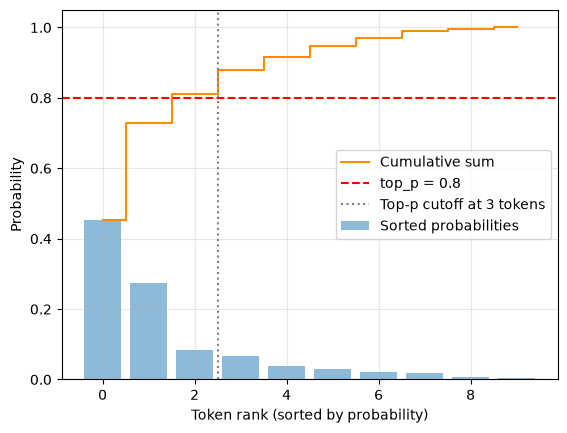

In [56]:
plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas,
    alpha=0.5, label="Sorted probabilities"
)
plt.step(
    torch.arange(len(cumsum)), cumsum, where="mid",
    color="darkorange", label="Cumulative sum"
)

plt.axhline(
    top_p, color="red", linestyle="--",
    label=f"top_p = {top_p}"
)
plt.axvline(
    n_kept - 0.5, color="gray", linestyle=":",
    label=f"Top-p cutoff at {n_kept} tokens"
)

plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

In [57]:
# now we must 0 out the values to the right of cut off and restore original sort order
kept_sorted = torch.where(
    keep_mask, sorted_probas,
    torch.zeros_like(sorted_probas)
)
filtered = torch.zeros_like(toy_probas).scatter(0, sorted_idx, kept_sorted)
filtered

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.4538, 0.0000, 0.0000, 0.0000, 0.0829,
        0.2752])

In [58]:
# normailze so they sum to one again
denom = torch.sum(filtered).clamp_min(1e-12)
renormalized = filtered / denom
renormalized

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5589, 0.0000, 0.0000, 0.0000, 0.1021,
        0.3390])

In [59]:
"""
The goal of this top-p filtering is to remove tokens with low probabilities so they aren’t
sampled later. This helps reduce nonsensical token responses in a given context.
"""
def top_p_filter(probas, top_p):
    if top_p is None or top_p >= 1.0:
        return probas

    sorted_probas, sorted_idx = torch.sort(probas, dim=1, descending=True)
    cumprobas = torch.cumsum(sorted_probas, dim=1)
    prefix = cumprobas - sorted_probas
    keep = prefix < top_p
    keep[:, 0] = True

    # zero out beyond cutoff
    kept_sorted = torch.where(
        keep, sorted_probas,
        torch.zeros_like(sorted_probas)
    )

    # map back to original order
    filtered = torch.zeros_like(probas).scatter(1, sorted_idx, kept_sorted)
    # renormalize to sum to 1
    denom = torch.sum(filtered, dim=1, keepdim=True).clamp_min(1e-12)
    return filtered / denom

In [60]:
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [62]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.65), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

'
': 15x
' a': 3x
' (': 3x
' __': 93x
' called': 7x
' located': 7x
' ___': 2x
' .
': 2x
' Tokyo': 748x
' ____': 71x
' ______': 14x
' Kyoto': 21x
' Osaka': 2x


In [63]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.65), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)
count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)

' __': 108x
' Tokyo': 892x


In [65]:
@torch.inference_mode()
def generate_text_top_p_stream_cache(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.,
    top_p=None
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):
        
        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)
        else:
            logits = scale_logits_by_temperature(out, temperature)
            probas = torch.softmax(logits, dim=-1) # convert to probabilities

            probas = top_p_filter(probas, top_p) # apply top_p filter to probabilities

            next_token = torch.multinomial(probas.cpu(), num_samples=1) # sample token according to probabilities
            next_token = next_token.to(orig_device)

        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [66]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.5,
    top_p=0.8,
)

 \boxed{18}

In [70]:
"""
In practice, it’s also common to generate the answers on different devices so the
sampling can be parallelized.
"""
from reasoning_from_scratch.ch03 import extract_final_candidate
from collections import Counter

def self_consistency_vote(
    model, tokenizer, prompt, device,
    num_samples=10, temperature=0.8, top_p=0.9, max_new_tokens=2048,
    show_progress=True, show_long_answer=False, seed=None,
):
    full_answers, short_answers = [], []

    for i in range(num_samples):
        if seed is not None:
            """
            this is not necessary, setting the random seed once is sufficient to
            generate diverse samples. This explicit seeding is useful if we want
            to rerun some of the rounds individually.
            """
            torch.manual_seed(seed + i + 1)

        answer = generate_text_stream_concat_flex(
            model=model, tokenizer=tokenizer, prompt=prompt, device=device,
            max_new_tokens=max_new_tokens, verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature, top_p=top_p,
        )
        short = extract_final_candidate(
            answer, fallback="number_then_full"
        )
        full_answers.append(answer)
        short_answers.append(short)
        if show_progress:
            print(f"[Sample {i+1}/{num_samples}] -> {short!r}")


    counts = Counter(short_answers)
    groups = {s: [] for s in counts}
    for idx, s in enumerate(short_answers):
        groups[s].append(idx)

    mc = counts.most_common()
    if not mc:
        majority_winners, final_answer = [], None
    else:
        top_freq = mc[0][1]
        majority_winners = [s for s, f in mc if f == top_freq]
        final_answer = mc[0][0] if len(majority_winners) == 1 else None

    return {
        "full_answers": full_answers,
        "short_answers": short_answers,
        "counts": dict(counts),
        "groups": groups,
        "majority_winners": majority_winners,
        "final_answer": final_answer,
    }

In [71]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt,
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] -> '83'
[Sample 2/5] -> '22'
[Sample 3/5] -> '54'
[Sample 4/5] -> '83'
[Sample 5/5] -> '61'


In [72]:
print(results["full_answers"][0])

 To find the value of \( x \), let's solve the equation step by step.

1. **Given Equation:**
   \[
   \text{Half the value of } 3x - 9 \text{ is } x + 37.
   \]
   This can be written as:
   \[
   \frac{1}{2}(3x - 9) = x + 37.
   \]

2. **Multiply Both Sides by 2 to Eliminate the Fraction:**
   \[
   2 \times \frac{1}{2}(3x - 9) = 2 \times (x + 37).
   \]
   Simplifying both sides:
   \[
   3x - 9 = 2x + 74.
   \]

3. **Subtract \( 2x \) from Both Sides to Get the \( x \)-terms on One Side:**
   \[
   3x - 2x - 9 = 74.
   \]
   Simplifying:
   \[
   x - 9 = 74.
   \]

4. **Add 9 to Both Sides to Solve for \( x \):**
   \[
   x - 9 + 9 = 74 + 9.
   \]
   Simplifying:
   \[
   x = 83.
   \]

**Final Answer:**
\[
\boxed{83}
\]


In [73]:
"""
combine chain-of-thought prompting with self-consistency sampling
"""
results = self_consistency_vote(
    model,
    tokenizer,
    prompt + "\n\nExplain step by step.",
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    seed=123,
    show_progress=True,
)

[Sample 1/5] -> '83'
[Sample 2/5] -> '83'
[Sample 3/5] -> '83'
[Sample 4/5] -> '83'
[Sample 5/5] -> '83'
